In [36]:
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('..','src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from DiagnosisTool.features import clean_breast_cancer_data

module_path = os.path.abspath(os.path.join('..',module_path,'DiagnosisTool'))

if module_path not in sys.path:
    sys.path.append(module_path)

from data import download_breast_cancer_file
from data import load_breast_cancer_data

download_breast_cancer_file()

breast_cancer_data = load_breast_cancer_data()

breast_cancer_data = clean_breast_cancer_data(breast_cancer_data)

breast_cancer_data.describe()

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


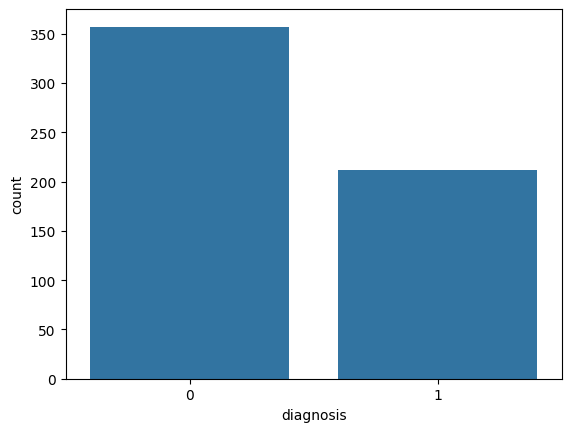

In [37]:
sns.countplot(x="diagnosis", data=breast_cancer_data)
plt.title="Distribuição das Classes de Diagnóstico (0: Benigno, 1: Maligno)"
plt.show()




### Discussão da variável alvo (diagnóstico)
- Dataset moderamente balanceado
- Leve predominância de tumores benignos
- Métricas além da eficiência são recomendadas

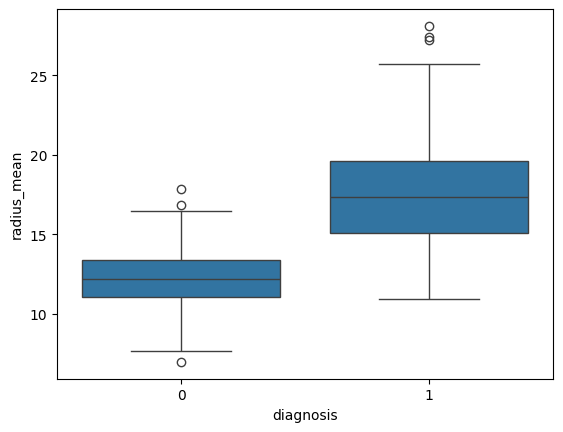

In [38]:
sns.boxplot(x="diagnosis",y="radius_mean",data=breast_cancer_data)
plt.title="Radius por Classe de Diagnóstico"
plt.show()



### Discussão de Radius por classe
- Tumores malignos apresentam raio (radius) médio maior
- Boa separabilidade visual
- Feature altamente discriminante

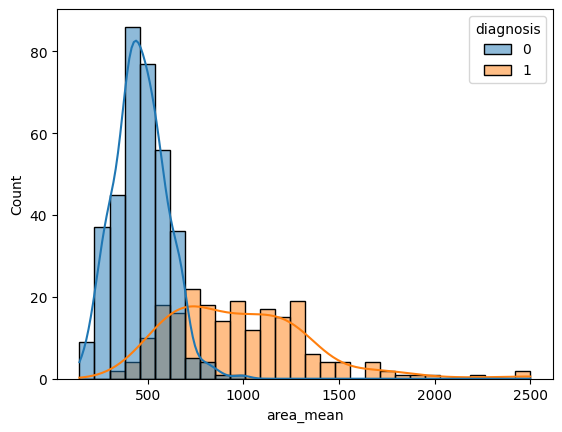

In [39]:
sns.histplot(data=breast_cancer_data, x="area_mean", hue="diagnosis", kde=True, bins=30)
plt.title="Distribuição de Área por Classe"
plt.show()



### Discussão de Área por Classe
- Distribuição dos malignos deslocada à direita
- Overlap limitado

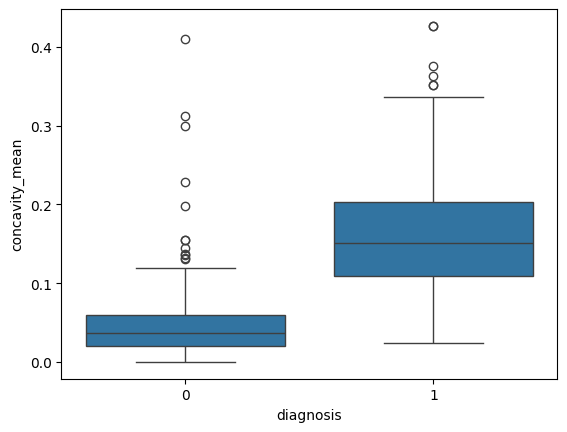

In [40]:
sns.boxplot(x="diagnosis", y="concavity_mean", data=breast_cancer_data)
plt.title="Distribuição de Concavidade por Classe"
plt.show()



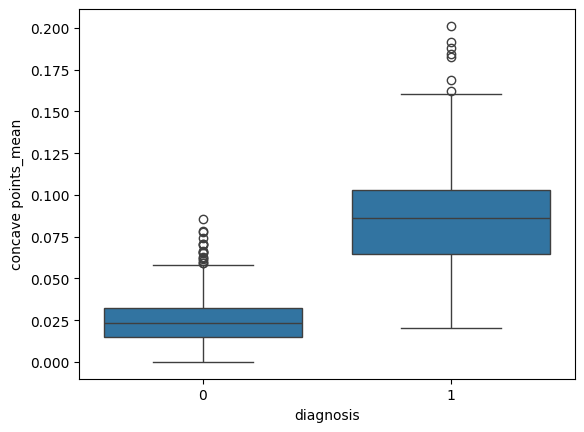

In [41]:
sns.boxplot(x="diagnosis", y="concave points_mean", data=breast_cancer_data)
plt.title="Distribuição de Pontos Concavos por Classe"
plt.show()



### Discussão sobre Concavity e Concave Points
- Tumores malignos apresentam valores significativamente maiores
- Bordas mais irregulares (maior agressividade tumoral)
- Algumas das features mais importantes do Dataset

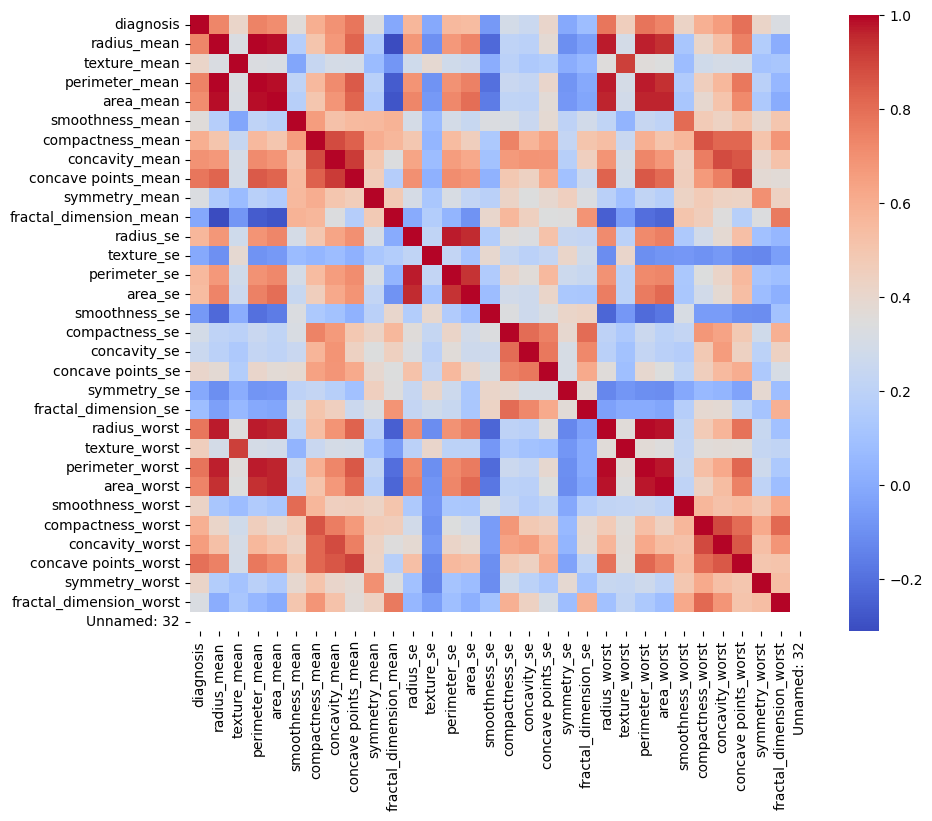

In [42]:
plt.figure(figsize=(10,8))
breast_cancer_data_numeric = breast_cancer_data.select_dtypes(include=['float64', 'int64'])
sns.heatmap(breast_cancer_data_numeric.corr(), cmap="coolwarm" , annot=False)
plt.show()

### Observações
- Forte correlação entre:
    - Radius, perimeter & area
    - Concavity & Concave Points
- Multicolinearidade presente (modelos lineares podem exigir regularização)

### Discussão geral dos resultados
#### Principais insights
- Features geométricas são altamente discriminativas
    - Radius, perimeter e area apresentam forte separação entre as classes
- Irregularidade de borda é fator-chave
    - Concavity e Concave Points são ótimos indicadores de malignidade
- Features isoladas não bastam
    - Variáveis como texture e smoothness têm baixo poder isoladamente, mas são valiosas em conjunto
- Dataset é limpo e bem estruturado
    - Não há ausência de valores